# Baseline Analysis

In [1]:
import polars as pl

import src.social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:138: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:143: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J,
    triple_underscore_handling="wrong",
    fill_nulls_with=False,
)

In [3]:
from social_groups.analysis.definitions import defs

baseline_output_frame: pl.DataFrame = defs().load_asset_value(
    "baseline_output_comparison"
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:111: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-03-20 15:34:03 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/baseline_output_comparison.parquet using PolarsParquetIOManager...


In [4]:
baseline_output_frame.head()

id,run_id,question_id,phoenix_span_url,run_identifier,final_answer,experiment_id,name,original_question_id,category,question,answer_string,model_name,with_few_shot_prompting,use_thinking
i64,i64,i64,str,str,str,i64,str,i64,str,str,str,str,bool,bool
3920,40,60,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The passage states that perest…",1,"""heterogeneous_group_baseline""",4888,"""history""","""Q: This question refers to the…","""H""","""Qwen/Qwen3-14B""",false,false
3921,40,65,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is (D): Growth in b…",1,"""heterogeneous_group_baseline""",3249,"""biology""","""Q: How does the term ""growth"" …","""D""","""Qwen/Qwen3-14B""",false,false
3922,40,63,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is **(C): Aortic di…",1,"""heterogeneous_group_baseline""",6037,"""health""","""Q: A 47-year-old man is brough…","""C""","""Qwen/Qwen3-14B""",false,false
3923,40,66,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is (A): unethically…",1,"""heterogeneous_group_baseline""",2626,"""psychology""","""Q: A non-custodial parent asks…","""J""","""Qwen/Qwen3-14B""",false,false
3924,40,62,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The Islamic understanding of j…",1,"""heterogeneous_group_baseline""",11057,"""philosophy""","""Q: Which of the following is N…","""E""","""Qwen/Qwen3-14B""",false,false


In [5]:
data = (
    baseline_output_frame.with_columns(parser(pl.col(plc.final_answer)).alias("PARSED"))
    .with_columns(
        comparer(pl.col("PARSED"), pl.col(plc.answer_string)).alias(plc.is_correct)
    )
    # .drop("PARSED")
    .with_columns(
        pl.col("model_name").replace(MODEL_NAME_TO_LETTER_MAPPING).alias("model"),
        pl.col("name")
        .replace(
            {
                "heterogeneous_group_baseline_tool": "tool",
                "heterogeneous_group_baseline_structured_output": "structured",
                "heterogeneous_group_baseline": "generation",
            }
        )
        .alias("method"),
    )
)

In [6]:
baseline_comparison = (
    data.group_by("method", "with_few_shot_prompting", "use_thinking", "model")
    .agg(pl.col(plc.is_correct).mean().alias(plc.accuracy))
    .sort(plc.accuracy, "use_thinking", "with_few_shot_prompting", descending=True)
)

register_materialization(
    "baseline_approach_comparison_table",
    baseline_comparison,
    "Comparing Accuracy of different methods of prompting.",
)

baseline_comparison

Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


method,with_few_shot_prompting,use_thinking,model,accuracy
str,bool,bool,str,f64
"""generation""",true,true,"""H""",0.7
"""generation""",false,true,"""H""",0.65
"""generation""",true,true,"""M""",0.63
"""generation""",false,false,"""M""",0.63
"""generation""",false,false,"""H""",0.62
…,…,…,…,…
"""generation""",false,true,"""L""",0.31
"""tool""",true,null,"""L""",0.3
"""generation""",false,false,"""L""",0.29


In [7]:
baseline_comparison.columns

['method', 'with_few_shot_prompting', 'use_thinking', 'model', 'accuracy']

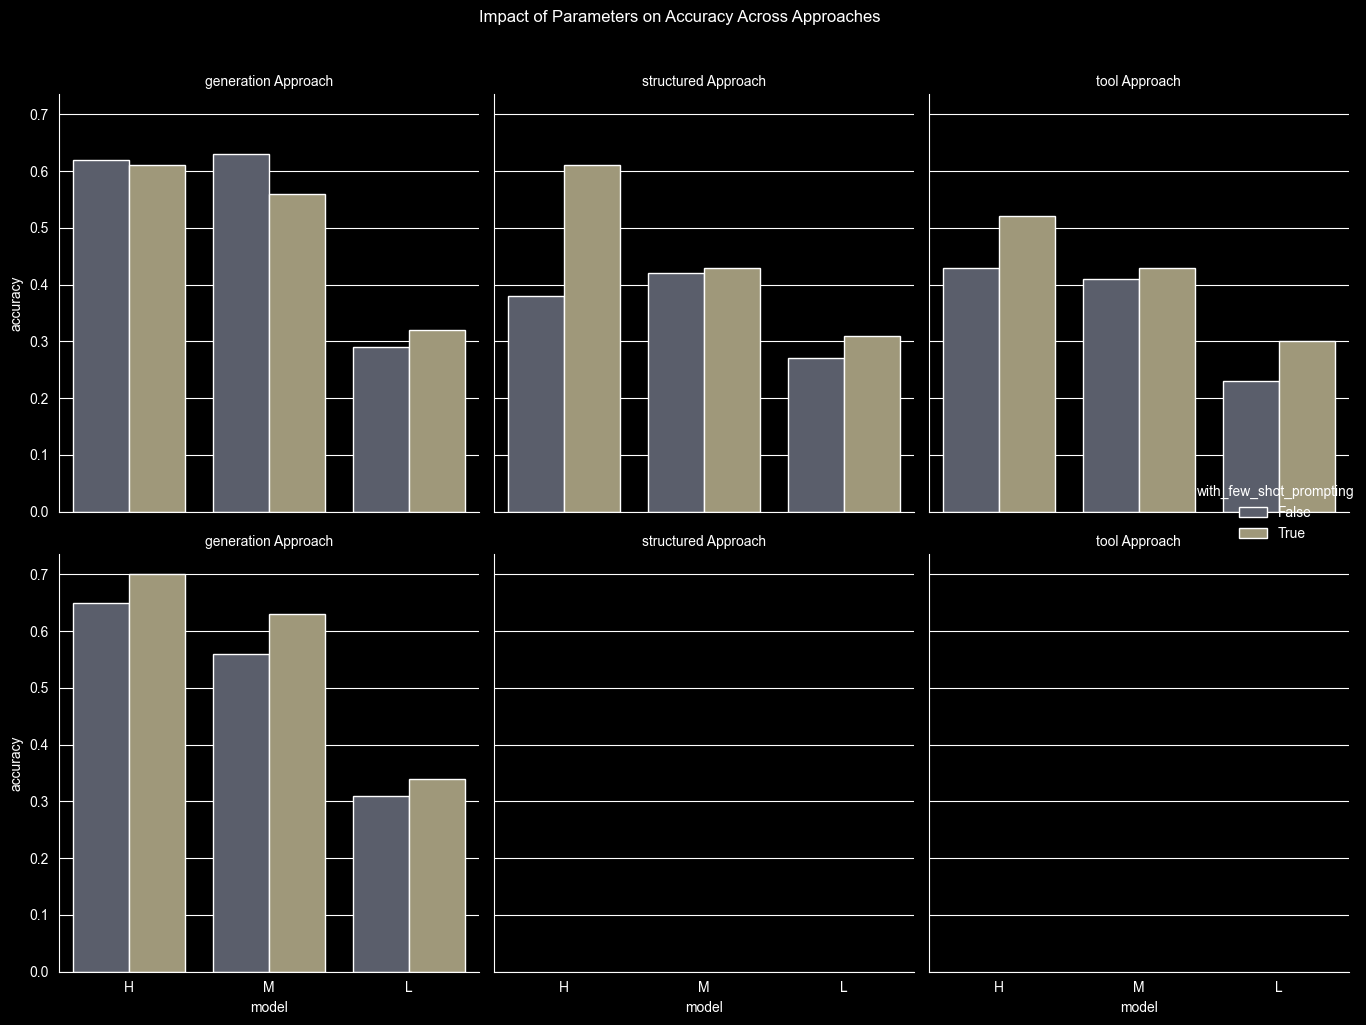

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=baseline_comparison.fill_null(False),
    x="model",
    y="accuracy",
    hue="with_few_shot_prompting",
    row="use_thinking",
    col="method",
    kind="bar",
    height=5,
    aspect=0.8,
    palette="cividis",
    legend="full",
)

g.set_titles("{col_name} Approach")
g.fig.suptitle("Impact of Parameters on Accuracy Across Approaches", y=1.02)

plt.tight_layout()
plt.show()

In [9]:
for a, b, c in (
    data.filter(
        (pl.col("method") == "generation")
        & (pl.col("use_thinking") == False)
        & (pl.col("with_few_shot_prompting") == True)
    )
    .select("question", "answer_string", "final_answer")
    .iter_rows()
):
    print(a)
    print("CORRECT", b)
    print(c)
    print("--------------------")

Q: A sample of bristle cone pine wood of age 7,000 \pm 100 years, known by counting growth rings, possesses an activity of 6.6 d (disinte-grations) /minute-g of carbon. Calculate the exact age of the wood sample from radiochemical evidence.
Options are:
(A): 6,750 years old
(B): 5,500 years old
(C): 6,000 years old
(D): 7,000 years old
(E): 6,225 years old
(F): 7,350 years old
(G): 5,730 years old
(H): 7,150 years old
(I): 6,400 years old
(J): 5,915 years old


CORRECT E
The exact age of the wood sample can be calculated using the formula for carbon dating:

$$
\text{Age} = \frac{6.6 \, \text{d}}{100} \times 7000
$$

$$
\text{Age} = 6.6 \times 70 = 462 \, \text{years}
$$

The answer is (A): 6,750 years old.
--------------------
Q: A wealthy woman often wore expensive jewelry while walking her dog in the park. Her friends warned her against wearing such valuable jewelry because they feared she would be an easy target for muggers. In order to persuade the woman not to wear her expensive 

In [10]:
# ExtraNotebookAsset(name="a_test_table_in_latex", extension="tex").register_materialization(baseline_output_frame, "This is a Test Table")

In [11]:
data

id,run_id,question_id,phoenix_span_url,run_identifier,final_answer,experiment_id,name,original_question_id,category,question,answer_string,model_name,with_few_shot_prompting,use_thinking,PARSED,is_correct,model,method
i64,i64,i64,str,str,str,i64,str,i64,str,str,str,str,bool,bool,str,bool,str,str
3920,40,60,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The passage states that perest…",1,"""heterogeneous_group_baseline""",4888,"""history""","""Q: This question refers to the…","""H""","""Qwen/Qwen3-14B""",false,false,"""H""",true,"""H""","""generation"""
3921,40,65,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is (D): Growth in b…",1,"""heterogeneous_group_baseline""",3249,"""biology""","""Q: How does the term ""growth"" …","""D""","""Qwen/Qwen3-14B""",false,false,"""D""",true,"""H""","""generation"""
3922,40,63,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is **(C): Aortic di…",1,"""heterogeneous_group_baseline""",6037,"""health""","""Q: A 47-year-old man is brough…","""C""","""Qwen/Qwen3-14B""",false,false,"""C""",true,"""H""","""generation"""
3923,40,66,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The answer is (A): unethically…",1,"""heterogeneous_group_baseline""",2626,"""psychology""","""Q: A non-custodial parent asks…","""J""","""Qwen/Qwen3-14B""",false,false,"""A""",false,"""H""","""generation"""
3924,40,62,"""http://localhost:6006/projects…","""2026-03-08-03-07-45 - heteroge…","""The Islamic understanding of j…",1,"""heterogeneous_group_baseline""",11057,"""philosophy""","""Q: Which of the following is N…","""E""","""Qwen/Qwen3-14B""",false,false,"""D""",false,"""H""","""generation"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
37855,369,16,"""http://localhost:6006/projects…","""2026-03-08-03-07-58 - heteroge…","""(I): he was such a brilliant m…",18,"""heterogeneous_group_baseline_t…",4911,"""history""","""Q: Pizarro was able to subdue …","""B""","""Qwen/Qwen3-0.6B""",false,null,"""I""",false,"""L""","""tool"""
37856,369,14,"""http://localhost:6006/projects…","""2026-03-08-03-07-58 - heteroge…","""(I): Gold, quartz, topaz, diam…",18,"""heterogeneous_group_baseline_t…",5886,"""other""","""Q: Which of the following list…","""I""","""Qwen/Qwen3-0.6B""",false,null,"""I""",true,"""L""","""tool"""
37857,369,63,"""http://localhost:6006/projects…","""2026-03-08-03-07-58 - heteroge…","""(J) Acute myocardial infarctio…",18,"""heterogeneous_group_baseline_t…",6037,"""health""","""Q: A 47-year-old man is brough…","""C""","""Qwen/Qwen3-0.6B""",false,null,"""J""",false,"""L""","""tool"""
